## Global Data Science Salary Analysis

### Project Objective
This project analyzes global data science salaries using a realistic synthetic dataset created with Python.

The project focuses on:
- salary trends
- experience impact
- remote work analysis
- country-wise salary comparison
- role-based salary insights
- data cleaning
- exploratory data analysis
- statistical analysis

The dataset was intentionally designed with realistic patterns, missing values, duplicates, typos, and outliers to simulate
real-world industry datasets.

In [44]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# load dataset
df = pd.read_csv("../data/raw_salary_dataset.csv")

### Dataset overview

In [46]:
# view first rows
df.head()

,employee_id,age,gender,country,city,education,experience_level,years_experience,job_title,industry,programming_langiage,company_size,remote_type,tools_used,certification,salary_usd,work_hours_per_week,satisfaction_score,promotion_last_2_years
0,1,22,Female,Australia,Jamesland,Bachelors,Lead,20,AI Engineer,Healthcare,R,Small,Remote,"Tableau, TensorFlow, Python",Microsoft Power BI,NaN,46,5.8,No
1,2,23,Other,India,West Derrick,Masters,Lead,13,Data Scntist,Gaming,Julia,Medium,Hybrid,"Pandas, SQL, Spark",None,NaN,38,8.4,No
2,3,44,Male,Canada,Luceroside,Bachelors,Lead,11,Machine Learning Engineer,Consulting,Julia,Medium,Hybrid,"Python, PyTorch, NumPy",AWS Certified,72818.0,56,8.5,No
3,4,36,Other,India,South Laurenberg,Masters,Lead,18,Data Scientist,E-commerce,SQL,Large,Onsite,"Spark, TensorFlow, Pandas",TensorFlow Developer,90184.0,32,4.3,Yes
4,5,25,Female,Germany,Obrienview,Masters,Entry,1,Data Analyst,Retail,R,Large,Remote,"PyTorch, Excel, NumPy",TensorFlow Developer,41244.0,55,5.3,Yes


In [47]:
df.shape

(2019, 19)

In [48]:
# check column names
df.columns

Index(['employee_id', 'age', 'gender', 'country', 'city', 'education',
       'experience_level', 'years_experience', 'job_title', 'industry',
       'programming_langiage', 'company_size', 'remote_type', 'tools_used',
       'certification', 'salary_usd', 'work_hours_per_week',
       'satisfaction_score', 'promotion_last_2_years'],
      dtype='object')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2019 entries, 0 to 2018
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   employee_id             2019 non-null   int64  
 1   age                     2019 non-null   int64  
 2   gender                  2019 non-null   object 
 3   country                 2019 non-null   object 
 4   city                    2019 non-null   object 
 5   education               2019 non-null   object 
 6   experience_level        2019 non-null   object 
 7   years_experience        2019 non-null   int64  
 8   job_title               2019 non-null   object 
 9   industry                2019 non-null   object 
 10  programming_langiage    2019 non-null   object 
 11  company_size            2019 non-null   object 
 12  remote_type             2019 non-null   object 
 13  tools_used              2019 non-null   object 
 14  certification           2019 non-null   

### Insight
The dataset contains multiple employee-related attributes including:
- country
- job role
- education
- experience
- salary
- remote work type

Initial inspection helps identify:
- dataset dimensions
- datatypes
- missing values
- preprocessing requirements

### Missing value analysis

In [50]:
df.isnull().sum()

employee_id                0
age                        0
gender                     0
country                    0
city                       0
education                  0
experience_level           0
years_experience           0
job_title                  0
industry                   0
programming_langiage       0
company_size               0
remote_type                0
tools_used                 0
certification              0
salary_usd                44
work_hours_per_week        0
satisfaction_score         0
promotion_last_2_years     0
dtype: int64

### Insight
The dataset contains missing salary values, which is a common issue in real-world datasets.

Proper handling of missing values is important because incomplete salary data can affect statistical analysis 
and salary trend interpretation.

In [51]:
# duplicate analysis
df.duplicated().sum()

20

In [52]:
df["job_title"].unique()

array(['AI Engineer', 'Data Scntist', 'Machine Learning Engineer',
       'Data Scientist', 'Data Analyst', 'Business Analyst', 'BI Analyst',
       'Data Engineer', 'Analytics Engineer'], dtype=object)

In [53]:
#create cleaning copy
cleaned_df = df.copy()

In [54]:
#check duplicate rows 
cleaned_df.duplicated().sum()

20

In [55]:
#remove duplicates
cleaned_df = cleaned_df.drop_duplicates()

In [56]:
cleaned_df.duplicated().sum()

0

### Insight
Duplicate employee records were intentionally introduced to simulate real-world data-entry issues.

Removing duplicate rows helps improve data reliability and prevents biased analysis results.

#### Categorical analysis

In [57]:
#check typo value
cleaned_df["job_title"].value_counts()

AI Engineer                  258
Data Scientist               258
Analytics Engineer           249
Business Analyst             244
Machine Learning Engineer    237
Data Engineer                233
Data Analyst                 232
BI Analyst                   231
Data Scntist                  57
Name: job_title, dtype: int64

In [58]:
# fix typo
cleaned_df["job_title"] = cleaned_df["job_title"].replace(
    "Data Scntist",
    "Data Scientist"
)

In [59]:
#verify 
cleaned_df["job_title"].value_counts()

Data Scientist               315
AI Engineer                  258
Analytics Engineer           249
Business Analyst             244
Machine Learning Engineer    237
Data Engineer                233
Data Analyst                 232
BI Analyst                   231
Name: job_title, dtype: int64

### Insight
The dataset contained inconsistent job title categories caused by spelling variations.

Standardizing category values improves grouping accuracy and ensures meaningful role-based analysis.

In [60]:
# check missing value
cleaned_df["salary_usd"].isnull().sum()

43

In [61]:
# handle missing salary
median_salary = cleaned_df["salary_usd"].median()
cleaned_df["salary_usd"] = cleaned_df["salary_usd"].fillna(median_salary)

In [62]:
cleaned_df["salary_usd"].isnull().sum()

0

### Insight
Missing salary values were imputed using the median salary because salary distributions are affected by extreme outliers.

Median imputation provides more robust results compared to mean imputation.

### outlier analysis

In [63]:
cleaned_df["salary_usd"].describe()

count    1.999000e+03
mean     7.162581e+04
std      5.733641e+04
min      9.018000e+03
25%      4.683700e+04
50%      6.507800e+04
75%      8.610600e+04
max      1.056496e+06
Name: salary_usd, dtype: float64

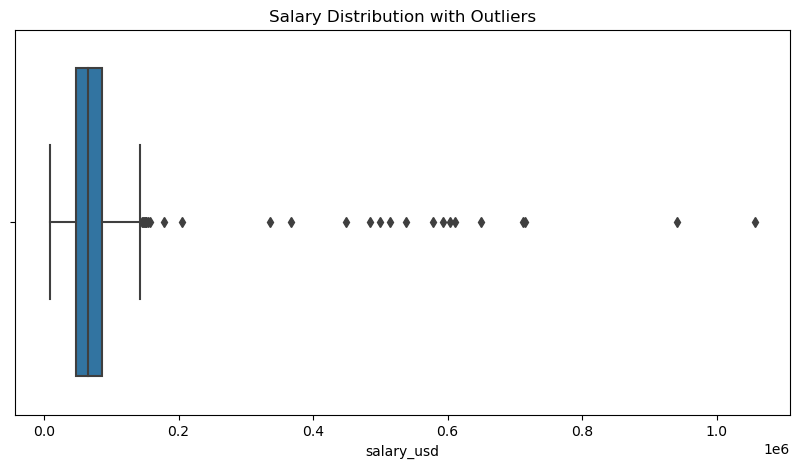

In [64]:
# visualize outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=cleaned_df["salary_usd"])
plt.title("Salary Distribution with Outliers")
plt.show()

In [65]:
#calculate IQR
Q1 = cleaned_df["salary_usd"].quantile(0.25)

Q3 = cleaned_df["salary_usd"].quantile(0.75)

IQR = Q3 - Q1

In [66]:
# define outlier bond
lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

In [67]:
# detect outlier
outliers = cleaned_df[
    (cleaned_df["salary_usd"] < lower_bound) |
    (cleaned_df["salary_usd"] > upper_bound)
]

### Insight
Several extreme salary values were identified within the dataset using the IQR (Interquartile Range) method.

These outliers may represent:
- senior executive positions
- highly specialized AI roles
- unusually high compensation packages

Outlier analysis is important because extreme salary values can significantly affect averages, statistical summaries, 
and visual interpretations.

In [68]:
# count outlier
len(outliers)

26

### Observation
The dataset contains multiple salary outliers, indicating a wide variation in compensation levels across different
countries, roles, and experience levels.

In [73]:
cleaned_df.rename(
    columns={"programming_langiage": "programming_language"},
    inplace=True
)

## Column Standardization

### Insight
A spelling inconsistency was identified in the dataset column names during exploratory analysis.
The column `langiage` was standardized to `programming_language` to improve readability, maintain 
consistency, and support cleaner analysis workflows.

In [74]:
print(cleaned_df.columns)

Index(['employee_id', 'age', 'gender', 'country', 'city', 'education',
       'experience_level', 'years_experience', 'job_title', 'industry',
       'programming_language', 'company_size', 'remote_type', 'tools_used',
       'certification', 'salary_usd', 'work_hours_per_week',
       'satisfaction_score', 'promotion_last_2_years'],
      dtype='object')


In [75]:
# save cleaned dataset
cleaned_df.to_csv("../data/cleaned_salary_dataset.csv", index=False)
print("DATASET UPDATED SUCCESSFULLY")

DATASET UPDATED SUCCESSFULLY


## Cleaned Dataset Export

### Insight
After preprocessing and cleaning, the refined dataset was exported for further exploratory and statistical analysis.

The cleaned dataset now contains:
- standardized categorical values
- handled missing values
- duplicate-free records
- analyzed salary outliers